# Does a Bayesian Fit Actually Fix Collinearity?

A common reaction to the diagnostic in this package: "we don't use plain OLS, we use a
Bayesian MMM, priors regularise the estimates, so this isn't our problem." This
notebook tests that claim directly.

**What we're comparing:** for the same simulated dataset, fit the channel elasticities
two ways — plain OLS (as `fit_ols` does throughout this package) with an analytic 95%
confidence interval, and a Bayesian linear model with weakly-informative priors (not
tuned to the true elasticities) via PyMC, using the 95% highest-density interval (HDI)
of the posterior. If priors regularise noisy estimates, the Bayesian interval should
come out narrower — the question is by how much, and whether it's enough to actually
solve the collinearity problem (spoiler: no — priors can't manufacture identifying
variation that isn't in the data; see the guide for the full argument).

In [1]:
# config
FAST_MODE = False  # set False for a publication-quality run (10 noise draws, more MCMC samples/chains)

In [2]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats

from how_wrong_is_your_mmm import simulate_sales, simulate_spend

warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")

CHANNEL_COLORS = {"tv": "#2563eb", "meta": "#d97706", "search": "#059669"}

/Users/ryanosullivan/Development/how_wrong_is_your_mmm/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## The setup

Same 3-channel toy example used throughout the project (TV, Meta, Search), but pushed
to a high correlation of 0.9 — the regime where collinearity actually bites and where
"just go Bayesian" sounds most tempting as a fix. The spend data itself is fixed
(one draw, correlation 0.9); what varies across simulations is the sales noise, so
we're asking "for this same collinear market, how much does the interval narrow when
we add priors?" rather than re-drawing the spend structure each time.

In [3]:
spend = simulate_spend(n_obs=104, correlation=0.9, seed=0)
channels = list(spend.columns)
X = spend[channels].to_numpy()
# Centre predictors for the Bayesian fit only (see note below) — OLS is unaffected
# by centering (it only shifts the intercept), so fit_ols_with_ci below uses raw X.
X_centered = X - X.mean(axis=0, keepdims=True)

actual_corr = spend.corr().to_numpy()
n = len(channels)
mean_pairwise_corr = np.mean(
    [actual_corr[i, j] for i in range(n) for j in range(i + 1, n)]
)
print(f"Channels: {channels}")
print(f"Actual mean pairwise correlation: {mean_pairwise_corr:.3f} (target 0.9)")

Channels: ['tv', 'meta', 'search']
Actual mean pairwise correlation: 0.894 (target 0.9)


## Two fitting methods

**OLS analytic 95% CI** — the standard textbook formula:
`beta_hat +/- t_crit * se`, where `se` comes from `sigma_hat^2 * (X'X)^-1` and
`t_crit` is the 97.5th percentile of a `t` distribution with `n - p` degrees of freedom.
This is what a classical `statsmodels`-style OLS summary would report; `fit_ols` in
this package returns the point estimate only, so we compute the interval separately here.

**Bayesian 95% HDI** — a PyMC linear model with:
- `intercept ~ Normal(mean(sales), 20,000)` — centred on the data, spread matched to
  the package's own `revenue_noise_std` default (a realistic assumption a practitioner
  could make from residual diagnostics, not a fitted parameter).
- `beta ~ Normal(0, 1)` per channel — weakly-informative and *not* tuned to the true
  elasticities (which sit at 0.2-0.6 in this package's DGP). A prior standard deviation
  of 1 allows swings far beyond anything plausible, while still being a proper
  (non-flat) prior.
- `sigma ~ HalfNormal(20,000)` — same reasoning as the intercept prior.
- 95% credible interval = the highest-density interval (HDI) of the `beta` posterior,
  via `arviz.hdi`.

**Why predictors are centred for the Bayesian fit.** An earlier version of this
notebook fit the Bayesian model on raw (uncentred) spend, with the intercept prior
centred on `mean(sales)`. That produced Bayesian intervals *wider* than OLS — the
opposite of what priors should ever do (a proper prior can only add information, so a
correctly-specified Bayesian posterior should never be wider than the flat-prior/OLS
equivalent). The cause: with an uncentred design matrix, `intercept` and `beta` are
aliased — spend values sit around 60,000-100,000, so tying the intercept tightly to
`mean(sales)` forces `beta` to absorb variation it wouldn't otherwise need to, inflating
its posterior spread. Centring each channel's spend around its own mean removes that
aliasing (a purely algebraic identity for OLS point estimates, and it fixes the
artefact for the Bayesian fit too). Worth remembering for any future Bayesian
comparison in this project: **centre predictors before setting an intercept prior.**

In [4]:
def fit_ols_with_ci(spend_df, sales, alpha=0.05):
    """OLS point estimate + analytic (1 - alpha) confidence interval width per channel."""
    channels = list(spend_df.columns)
    design = np.column_stack(
        [np.ones(len(spend_df))] + [spend_df[c].to_numpy() for c in channels]
    )
    y = sales.to_numpy()
    n_obs, n_params = design.shape
    beta_hat, *_ = np.linalg.lstsq(design, y, rcond=None)
    resid = y - design @ beta_hat
    sigma2_hat = np.sum(resid**2) / (n_obs - n_params)
    cov = sigma2_hat * np.linalg.inv(design.T @ design)
    se = np.sqrt(np.diag(cov))
    t_crit = stats.t.ppf(1 - alpha / 2, df=n_obs - n_params)
    width = 2 * t_crit * se
    return {c: width[i + 1] for i, c in enumerate(channels)}


def fit_bayesian_hdi(
    x_centered, sales, channels, seed, draws, tune, chains, hdi_prob=0.95
):
    """Bayesian linear fit on centred predictors, returns 95% HDI width per channel."""
    y = sales.to_numpy()
    with pm.Model():
        intercept = pm.Normal("intercept", mu=y.mean(), sigma=20_000)
        beta = pm.Normal("beta", mu=0, sigma=1, shape=len(channels))
        sigma = pm.HalfNormal("sigma", sigma=20_000)
        mu = intercept + pm.math.dot(x_centered, beta)
        pm.Normal("obs", mu=mu, sigma=sigma, observed=y)
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=1,
            progressbar=False,
            random_seed=seed,
            target_accept=0.9,
        )
    hdi = az.hdi(idata, var_names=["beta"], hdi_prob=hdi_prob)["beta"].values
    widths = {c: float(hdi[i, 1] - hdi[i, 0]) for i, c in enumerate(channels)}
    n_divergences = int(idata.sample_stats.diverging.sum())
    max_rhat = float(az.rhat(idata, var_names=["beta"])["beta"].max())
    return widths, n_divergences, max_rhat

## Averaging over noise draws

A single noise draw is not a reliable basis for this comparison: a single-sample
confidence interval can itself be a lucky or unlucky draw, which would confound the
comparison with sampling noise rather than a real difference between methods. We
average across `N_DRAWS` independent noise seeds instead, same fixed spend data, OLS
and Bayesian fit on each, widths averaged at the end. `FAST_MODE` trims the draw count
and MCMC sample size for quick iteration; the committed, citable numbers come from a
`FAST_MODE = False` run.

In [5]:
N_DRAWS = 3 if FAST_MODE else 10
MCMC_DRAWS = 300 if FAST_MODE else 1000
MCMC_TUNE = 300 if FAST_MODE else 1000
MCMC_CHAINS = 2 if FAST_MODE else 4

records = []
for draw_seed in range(N_DRAWS):
    sales = simulate_sales(spend, seed=draw_seed)
    ols_widths = fit_ols_with_ci(spend, sales)
    bayes_widths, n_divergences, max_rhat = fit_bayesian_hdi(
        X_centered,
        sales,
        channels,
        seed=draw_seed,
        draws=MCMC_DRAWS,
        tune=MCMC_TUNE,
        chains=MCMC_CHAINS,
    )
    for c in channels:
        records.append(
            {
                "draw": draw_seed,
                "channel": c,
                "ols_width": ols_widths[c],
                "bayes_width": bayes_widths[c],
                "narrowing_pct": 100
                * (bayes_widths[c] - ols_widths[c])
                / ols_widths[c],
                "n_divergences": n_divergences,
                "max_rhat": max_rhat,
            }
        )

results = pd.DataFrame(records)
print(
    f"Ran {N_DRAWS} noise draws, {MCMC_DRAWS} MCMC draws x {MCMC_CHAINS} chains each."
)
print(f"Max divergences across all fits: {results['n_divergences'].max()}")
print(
    f"Max r_hat across all fits: {results['max_rhat'].max():.4f}  (should be close to 1.0)"
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [intercept, beta, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 257 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [intercept, beta, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 248 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [intercept, beta, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 301 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [intercept, beta, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 245 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [intercept, beta, sigma]


Ran 10 noise draws, 1000 MCMC draws x 4 chains each.
Max divergences across all fits: 0
Max r_hat across all fits: 1.0026  (should be close to 1.0)


## Convergence check

Before trusting any interval widths, a quick sanity check: zero divergent transitions
and `r_hat` close to 1.0 across all fits means NUTS actually explored the posterior
properly, rather than an inflated or understated HDI being an artefact of poor
sampling. If either of these looks bad, the widths below aren't trustworthy —
increase `MCMC_TUNE` / `target_accept` before reading anything into the numbers.

In [6]:
assert results["n_divergences"].max() == 0, (
    "Divergent transitions found — widths below are not trustworthy, increase tuning."
)
assert results["max_rhat"].max() < 1.05, (
    "r_hat too high — chains have not converged, increase tuning/draws."
)
print("Convergence checks passed.")

Convergence checks passed.


In [7]:
summary = (
    results.groupby("channel")
    .agg(
        ols_mean_width=("ols_width", "mean"),
        bayes_mean_width=("bayes_width", "mean"),
        narrowing_pct=("narrowing_pct", "mean"),
        narrowing_pct_min=("narrowing_pct", "min"),
        narrowing_pct_max=("narrowing_pct", "max"),
    )
    .round(3)
    .reindex(channels)
)
summary

,ols_mean_width,bayes_mean_width,narrowing_pct,narrowing_pct_min,narrowing_pct_max
channel,,,,,
tv,0.929,0.862,-6.459,-10.787,2.538
meta,0.984,0.926,-5.159,-9.502,2.629
search,1.639,1.473,-9.101,-13.812,1.223


## Reading the result

Negative `narrowing_pct` means the Bayesian interval came out narrower than OLS — the
priors did some work. The `_min`/`_max` columns show the per-draw range: if it crosses
zero, some individual noise draws showed the Bayesian interval come out *wider* than
OLS for that specific draw (sampling noise in a single comparison, not a real effect —
this is exactly the "single draw is unreliable" trap from the markdown above). The
mean across draws is the number that matters.

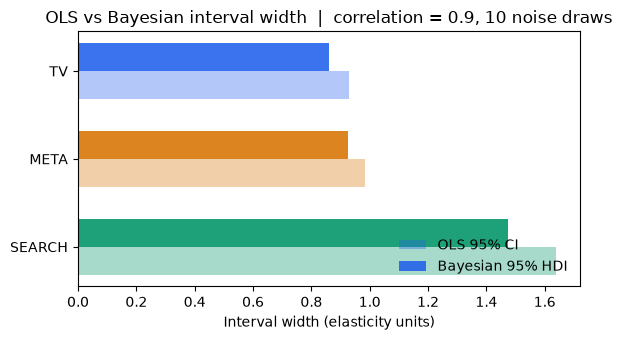

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5))
y_pos = np.arange(len(channels))
bar_h = 0.32

for i, c in enumerate(channels):
    ols_w = summary.loc[c, "ols_mean_width"]
    bayes_w = summary.loc[c, "bayes_mean_width"]
    color = CHANNEL_COLORS[c]
    ax.barh(
        i + bar_h / 2,
        ols_w,
        height=bar_h,
        color=color,
        alpha=0.35,
        label="OLS 95% CI" if i == 0 else None,
    )
    ax.barh(
        i - bar_h / 2,
        bayes_w,
        height=bar_h,
        color=color,
        alpha=0.9,
        label="Bayesian 95% HDI" if i == 0 else None,
    )

ax.set_yticks(y_pos)
ax.set_yticklabels([c.upper() for c in channels])
ax.set_xlabel("Interval width (elasticity units)")
ax.set_title(
    f"OLS vs Bayesian interval width  |  correlation = 0.9, {N_DRAWS} noise draws"
)
ax.legend(loc="lower right", frameon=False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Limitations

This is one scenario — 3 channels, correlation 0.9, one particular weakly-informative
prior choice, one DGP. It's not a claim that all Bayesian MMMs behave this way; it's a
grounded, re-runnable version of the specific comparison the guide already makes. The
takeaway matches the guide's framing either way: a sensible weakly-informative prior
buys a modest, real narrowing, nowhere near enough to resolve an identification
problem that phasing (Part 2 of this package) actually fixes by adding independent
variation the data didn't have before.